In [10]:
import utils
import numpy as np
from ax.service.ax_client import AxClient, ObjectiveProperties
from ax.modelbridge.factory import Generators
from ax.modelbridge.generation_strategy import GenerationStep, GenerationStrategy
from botorch.acquisition import ExpectedImprovement

from ax.service.utils.best_point import get_trace

import matplotlib.pyplot as plt

import time

In [ ]:
seed_list = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
obj1_name = 'f1'
obj2_name = 'f2'
obj3_name = 'f3'

models_list = [Generators.SAASBO, Generators.BO_MIXED, Generators.BOTORCH_MODULAR]

total_trials = 120

sobol_count = 100
trial_num = total_trials - sobol_count

trial_parameters = [
    {"name": "x1", "type": "range", "bounds": [-np.pi, np.pi], "value_type": "float"},
    {"name": "x2", "type": "range", "bounds": [-3.0, 3.0], "value_type": "float"},
    {"name": "x3", "type": "range", "bounds": [-np.pi, np.pi], "value_type": "float"},
    {"name": "x4", "type": "range", "bounds": [-3.0, 3.0], "value_type": "float"},
    {"name": "x5", "type": "range", "bounds": [-np.pi, np.pi], "value_type": "float"},
    {"name": "x6", "type": "range", "bounds": [-3.0, 3.0], "value_type": "float"},
    {"name": "x7", "type": "range", "bounds": [-3.0, 3.0], "value_type": "float"},
    {"name": "x8", "type": "range", "bounds": [-3.0, 3.0], "value_type": "float"},
    {"name": "x9", "type": "range", "bounds": [-3.0, 3.0], "value_type": "float"},
    {"name": "x10", "type": "range", "bounds": [-3.0, 3.0], "value_type": "float"},
    {"name": "x11", "type": "range", "bounds": [-np.pi, np.pi], "value_type": "float"},
    {"name": "x12", "type": "range", "bounds": [-np.pi, np.pi], "value_type": "float"},
    {"name": "x13", "type": "range", "bounds": [-3.0, 3.0], "value_type": "float"},
    {"name": "x14", "type": "range", "bounds": [-3.0, 3.0], "value_type": "float"}
]

trial_objectives = {
    obj1_name: ObjectiveProperties(minimize=True),
    obj2_name: ObjectiveProperties(minimize=True),
    obj3_name: ObjectiveProperties(minimize=True),
}

In [17]:
traces = []
for model in models_list:
    traces.append(np.zeros((len(seed_list), total_trials)))

times = []
for model in models_list:
    times.append(np.zeros((len(seed_list), total_trials)))

[WARNING 07-09 11:32:37] ax.service.ax_client: Random seed set to 0. Note that this setting only affects the Sobol quasi-random generator and BoTorch-powered Bayesian optimization models. For the latter models, setting random seed to the same number for two optimizations will make the generated trials similar, but not exactly the same, and over time the trials will diverge more.
[WARNING 07-09 11:32:37] ax.service.utils.instantiation: Objective thresholds were not set. They will be selected using a heuristic, but should be specified on the objective for best performance.
[WARNING 07-09 11:32:39] ax.service.ax_client: Random seed set to 0. Note that this setting only affects the Sobol quasi-random generator and BoTorch-powered Bayesian optimization models. For the latter models, setting random seed to the same number for two optimizations will make the generated trials similar, but not exactly the same, and over time the trials will diverge more.
[WARNING 07-09 11:32:39] ax.service.util

[276.01737238 276.01737238 329.84614872 329.84614872 329.84614872
 329.84614872 329.84614872 329.84614872 330.70339421 330.70339421
 330.70339421 330.70339421 330.70339421 351.69430826 351.69430826
 351.69430826 593.79276483 593.79276483 593.79276483 593.79276483
 593.79276483 593.79276483 593.79276483 593.79276483 593.79276483
 593.79276483 593.79276483 593.79276483 593.79276483 596.34770891
 596.34770891 596.34770891 596.35228012 596.35228012 596.35228012
 596.35228012 596.35228012 596.35228012 596.35239672 596.35239672
 596.35239672 596.35239672 596.35239672 596.35239672 596.35239672
 596.35239672 596.35239672 596.35239672 603.63989898 603.63989898
 603.63989898 603.63989898 604.03294228 604.03294228 604.03294228
 604.03294228 604.03294228 604.03294228 604.03294228 604.03294228
 604.03294228 604.03294228 604.03294228 604.03294228 604.03294228
 604.03294228 604.03294228 604.03294228 604.03294228 604.03294228
 604.03294228 604.03294228 604.03294228 604.03294228 634.54377634
 634.54377

[WARNING 07-09 11:34:56] ax.service.ax_client: Random seed set to 0. Note that this setting only affects the Sobol quasi-random generator and BoTorch-powered Bayesian optimization models. For the latter models, setting random seed to the same number for two optimizations will make the generated trials similar, but not exactly the same, and over time the trials will diverge more.
[WARNING 07-09 11:34:56] ax.service.utils.instantiation: Objective thresholds were not set. They will be selected using a heuristic, but should be specified on the objective for best performance.


[223.29269894 223.29269894 250.81930493 250.81930493 250.81930493
 250.81930493 250.81930493 250.81930493 251.67655042 251.67655042
 251.67655042 251.67655042 251.67655042 272.66746447 272.66746447
 272.66746447 452.58826897 452.58826897 452.58826897 452.58826897
 452.58826897 452.58826897 452.58826897 452.58826897 452.58826897
 452.58826897 452.58826897 452.58826897 452.58826897 455.14321305
 455.14321305 455.14321305 455.14778425 455.14778425 455.14778425
 455.14778425 455.14778425 455.14778425 455.14779856 455.14779856
 455.14779856 455.14779856 455.14779856 455.14779856 455.14779856
 455.14779856 455.14779856 455.14779856 462.43530082 462.43530082
 462.43530082 462.43530082 462.82834411 462.82834411 462.82834411
 462.82834411 462.82834411 462.82834411 462.82834411 462.82834411
 462.82834411 462.82834411 462.82834411 462.82834411 462.82834411
 462.82834411 462.82834411 462.82834411 462.82834411 462.82834411
 462.82834411 462.82834411 462.82834411 462.82834411 482.78931109
 482.78931

/opt/anaconda3/envs/drug_surfactant/lib/python3.11/site-packages/botorch/acquisition/analytic.py:331: NumericsWarning: ExpectedImprovement has known numerical issues that lead to suboptimal optimization performance. It is strongly recommended to simply replace

	 ExpectedImprovement 	 --> 	 LogExpectedImprovement 

instead, which fixes the issues and has the same API. See https://arxiv.org/abs/2310.20708 for details.
  legacy_ei_numerics_warning(legacy_name=type(self).__name__)
[WARNING 07-09 11:35:18] ax.service.ax_client: Random seed set to 1. Note that this setting only affects the Sobol quasi-random generator and BoTorch-powered Bayesian optimization models. For the latter models, setting random seed to the same number for two optimizations will make the generated trials similar, but not exactly the same, and over time the trials will diverge more.
[WARNING 07-09 11:35:18] ax.service.utils.instantiation: Objective thresholds were not set. They will be selected using a heuristic, bu

...

[  8.35632239   8.35632239 100.28184844 100.28184844 100.28184844
 134.01286682 134.01286682 343.36401543 343.36401543 343.36401543
 343.36401543 343.36401543 343.36401543 363.81784584 363.81784584
 392.58867893 392.58867893 392.58867893 404.29530013 404.29530013
 404.29530013 404.29530013 404.29530013 404.31279113 404.31279113
 404.31279113 404.31279113 404.31279113 404.31279113 415.58659326
 415.58659326 431.09992528 431.09992528 431.09992528 431.09992528
 431.09992528 431.09992528 431.26642644 431.26642644 538.21888709
 538.21888709 538.21888709 538.21888709 538.21888709 538.21888709
 538.21888709 538.21888709 541.61654336 541.61654336 541.61654336
 541.61654336 541.61654336 541.61654336 553.53530138 553.53530138
 554.98186902 554.98186902 554.98186902 556.15981052 556.15981052
 556.15981052 556.15981052 556.15981052 556.15981052 556.15981052
 556.15981052 556.15981052 556.15981052 556.15981052 557.62244693
 557.62244693 558.00896893 558.00896893 558.00896893 558.00896893
 558.00896

/opt/anaconda3/envs/drug_surfactant/lib/python3.11/site-packages/botorch/acquisition/analytic.py:331: NumericsWarning: ExpectedImprovement has known numerical issues that lead to suboptimal optimization performance. It is strongly recommended to simply replace

	 ExpectedImprovement 	 --> 	 LogExpectedImprovement 

instead, which fixes the issues and has the same API. See https://arxiv.org/abs/2310.20708 for details.
  legacy_ei_numerics_warning(legacy_name=type(self).__name__)
[WARNING 07-09 11:38:40] ax.service.ax_client: Random seed set to 2. Note that this setting only affects the Sobol quasi-random generator and BoTorch-powered Bayesian optimization models. For the latter models, setting random seed to the same number for two optimizations will make the generated trials similar, but not exactly the same, and over time the trials will diverge more.
[WARNING 07-09 11:38:40] ax.service.utils.instantiation: Objective thresholds were not set. They will be selected using a heuristic, bu

[ 12.66716295  12.66716295 146.28376276 146.28376276 146.28376276
 229.99497578 229.99497578 468.99081779 468.99081779 468.99081779
 468.99081779 468.99081779 468.99081779 495.0723946  495.0723946
 530.80446685 530.80446685 530.80446685 542.51108805 542.51108805
 542.51108805 542.51108805 542.51108805 542.52857905 542.52857905
 542.52857905 542.52857905 542.52857905 542.52857905 560.58436726
 560.58436726 576.09769928 576.09769928 576.09769928 576.09769928
 576.09769928 576.09769928 576.4420805  576.4420805  743.88113237
 743.88113237 743.88113237 743.88113237 743.88113237 743.88113237
 743.88113237 743.88113237 747.27878864 747.27878864 747.27878864
 747.27878864 747.27878864 747.27878864 768.19611263 768.19611263
 769.64268027 769.64268027 769.64268027 770.82062177 770.82062177
 770.82062177 770.82062177 770.82062177 770.82062177 770.82062177
 770.82062177 770.82062177 770.82062177 770.82062177 772.28325818
 772.28325818 772.66978018 772.66978018 772.66978018 772.66978018
 772.669780

[WARNING 07-09 11:38:41] ax.service.ax_client: Random seed set to 2. Note that this setting only affects the Sobol quasi-random generator and BoTorch-powered Bayesian optimization models. For the latter models, setting random seed to the same number for two optimizations will make the generated trials similar, but not exactly the same, and over time the trials will diverge more.
[WARNING 07-09 11:38:41] ax.service.utils.instantiation: Objective thresholds were not set. They will be selected using a heuristic, but should be specified on the objective for best performance.


KeyboardInterrupt: 

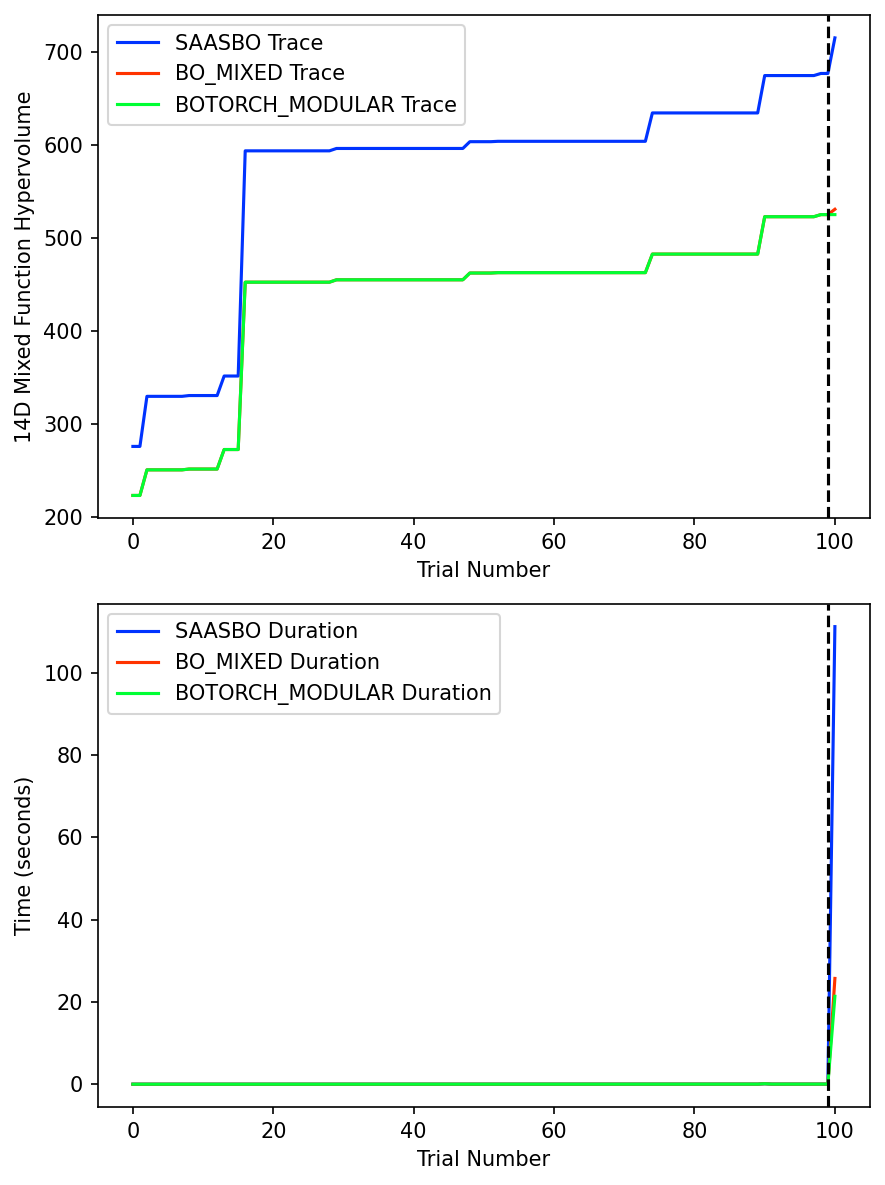

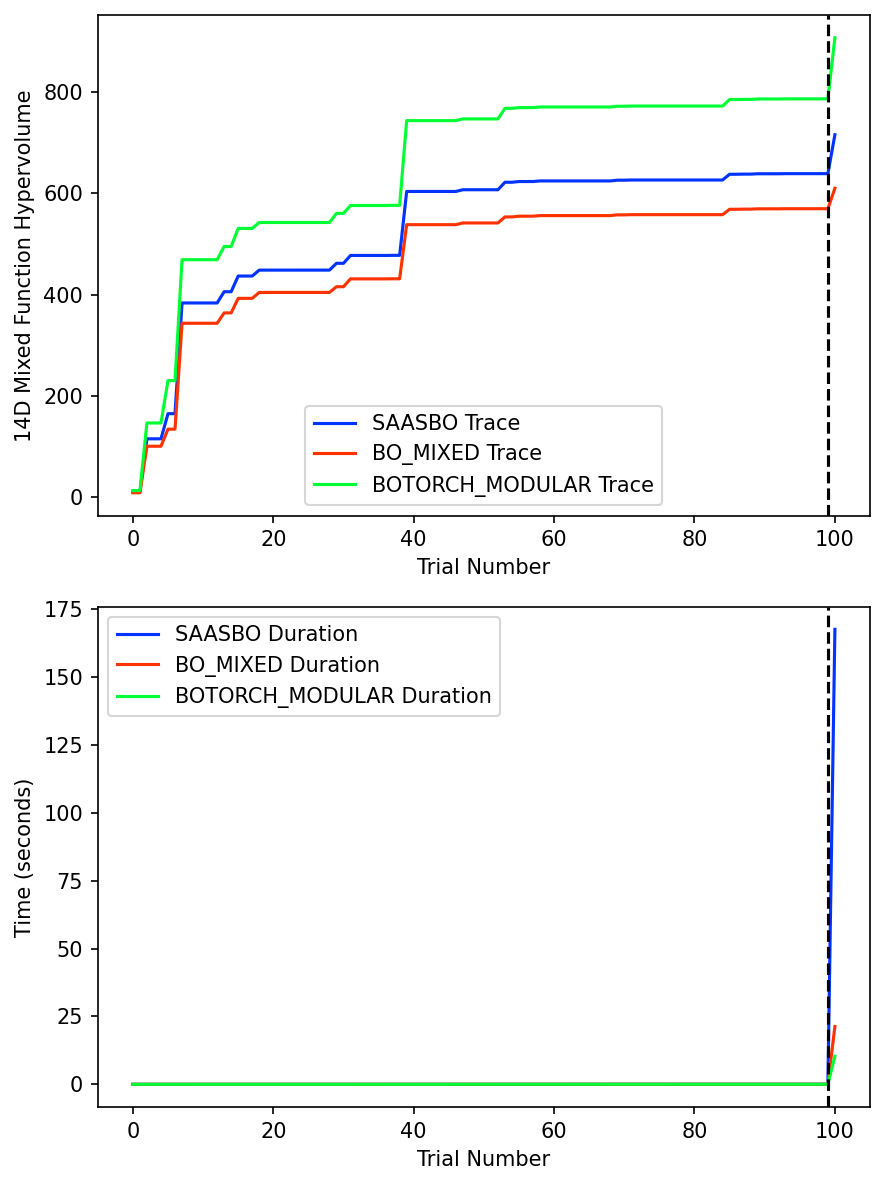

In [18]:
for j, seed in enumerate(seed_list):
    utils.set_seeds(seed)  # setting the random seed for reproducibility

    # generate same sobol trials for all models
    sobol_trials = []
    sobol_client = AxClient(
        generation_strategy=GenerationStrategy(
            steps=[
                GenerationStep(
                    model=Generators.SOBOL,
                    num_trials=sobol_count,
                    min_trials_observed=3,
                    max_parallelism=5,
                    model_kwargs={"seed": seed},
                    model_gen_kwargs={},
                ),
            ]
        ),
        verbose_logging=False,
        random_seed=seed)
    
    sobol_client.create_experiment(
        parameters=trial_parameters,
        objectives=trial_objectives,
    )

    for a in range(sobol_count):
        start_time = time.time()
        parameterization, trial_index = sobol_client.get_next_trial()
        time_taken = time.time() - start_time
        
        for mod_time in times:
            mod_time[j, a] = time_taken

        x = np.array([parameterization[f"x{i+1}"] for i in range(14)])

        results = utils.polynomial_14d(x)
        sobol_trials.append([results, parameterization])
        sobol_client.complete_trial(trial_index=trial_index, raw_data=results)

    for i, model in enumerate(models_list):
        gs = GenerationStrategy(
            steps=[
                #GenerationStep(
                #    model=Generators.SOBOL,
                #    num_trials=sobol_count,
                #    min_trials_observed=3,
                #    max_parallelism=5,
                #    model_kwargs={"seed": seed},
                #    model_gen_kwargs={},
                #),
                GenerationStep(
                    model=model,
                    num_trials=-1,
                    max_parallelism=3,
                    model_kwargs={"botorch_acqf_class": ExpectedImprovement} if model == Generators.BOTORCH_MODULAR else {},
                ),
            ]
        )

        ax_client = AxClient(generation_strategy=gs,
                                verbose_logging=False,
                                random_seed=seed)

        ax_client.create_experiment(
            parameters=trial_parameters,
            objectives=trial_objectives,
        )

        for a, (result, parameterization) in enumerate(sobol_trials):
            ax_client.attach_trial(parameters=parameterization)
            ax_client.complete_trial(trial_index=a, raw_data=result)
        traces[i][j, :sobol_count] = get_trace(ax_client._experiment)[:sobol_count]

        for a in range(trial_num):
            start_time = time.time()
            parameterization, trial_index = ax_client.get_next_trial()
            times[i][j, sobol_count + a] = time.time() - start_time

            x = np.array([parameterization[f"x{i+1}"] for i in range(14)])

            results = utils.mixed_14d(x)
            ax_client.complete_trial(trial_index=trial_index, raw_data=results)

        traces[i][j, :] = get_trace(ax_client._experiment)#[sobol_count:]
        print(traces[i][j, :], "for model:", i, "seed:", seed)
        print(times[i][j, :], "for model:", i, "seed:", seed)
    
    # plot for each seed
    objective = '14D Mixed Function Hypervolume'
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 8), dpi=150)

    for trace, duration, name in zip(traces, times, ["SAASBO", "BO_MIXED", "BOTORCH_MODULAR"]):

        color = '#0033FF' if name == "SAASBO" else '#FF3300'
        color = '#00FF33' if name == "BOTORCH_MODULAR" else color

        ax1.plot(trace[j], color=color, label=f"{name} Trace")
        print(seed, trace[j])

        ax2.plot(duration[j], color=color, label=f"{name} Duration")
        print(seed, duration[j])

    for ax in [ax1, ax2]:
        ax.axvline(sobol_count - 1, color='black', linestyle='--') # mark end of SOBOL trials
        ax.set_xlabel("Trial Number")
        ax.legend()

    ax1.set_ylabel(objective)

    ax2.set_ylabel("Time (seconds)")

    plt.tight_layout()
    #plt.show()
    plt.savefig("14_parameter_benches/mixed_multi_macmini/gen_strategy_bench_mixed14D_seed{}.png".format(seed), dpi=150)


In [ ]:

# plot everything together
objective = '14D Mixed Function Hypervolume'

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 8), dpi=150)

for trace, duration, name in zip(traces, times, ["SAASBO", "BO_MIXED", "BOTORCH_MODULAR"]):

    trace_mean = np.mean(trace, axis=0)
    trace_std = np.std(trace, axis=0)

    duration_mean = np.mean(duration, axis=0)
    duration_std = np.std(duration, axis=0)

    color = '#0033FF' if name == "SAASBO" else '#FF3300'
    color = '#00FF33' if name == "BOTORCH_MODULAR" else color

    ax1.plot(trace_mean, color=color, label=f"{name} Mean")
    ax1.fill_between(
        range(len(trace_mean)), trace_mean - trace_std, trace_mean + trace_std,
        color=color, alpha=0.3, label=f"{name} Std Dev"
    )

    ax2.plot(duration_mean, color=color, label=f"{name} Duration Mean")
    ax2.fill_between(
        range(len(duration_mean)), duration_mean - duration_std, duration_mean + duration_std,
        color=color, alpha=0.3, label=f"{name} Duration Std Dev"
    )

for ax in [ax1, ax2]:
    ax.axvline(sobol_count - 1, color='black', linestyle='--') # mark end of SOBOL trials
    ax.set_xlabel("Trial Number")
    ax.legend()

ax1.set_ylabel(objective)

ax2.set_ylabel("Time (seconds)")
#plt.show()
plt.savefig("14_parameter_benches/mixed_multi_macmini/gen_strategy_bench_mixed14D_mean_and_std.png", dpi=150)